# 05 从线性模型到过拟合：MLP、容量与正则化

对应第7次课动手环节，建立在 `04_pytorch_power_model.ipynb` 之上。

三个实验，回答三个问题：

1. 加一层隐藏层（MLP）之后，验证误差真的变小了吗？
2. 隐藏层越大越好吗？什么时候验证误差反而上升？
3. 权重衰减（weight decay）怎样把过拟合压回去？

跑每个实验之前，先写下你的预测，再运行。

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

# 与 04 完全相同的数据处理，保证可比性
BASE = Path.cwd()
if BASE.name == 'notebooks':
    BASE = BASE.parent
DATA = BASE.parent / '2026-09-17 第一次课' / '重写论文' / 'analysis' / 'inputs' / 'top500_full.csv'
top500 = pd.read_csv(DATA)
reported = top500[top500['Power (kW)'].notna()].copy()
reported['has_accelerator'] = reported['Accelerator/Co-Processor'].notna().astype(float)
reported = reported.sample(frac=1, random_state=42).reset_index(drop=True)

X_np = np.column_stack([
    np.log10(reported['Rmax [TFlop/s]'].to_numpy()),
    reported['has_accelerator'].to_numpy(),
    (reported['Year'].to_numpy() - 2020) / 10,
]).astype('float32')
y_np = np.log10(reported['Power (kW)'].to_numpy()).astype('float32').reshape(-1, 1)

X_mean = X_np.mean(axis=0, keepdims=True)
X_std = X_np.std(axis=0, keepdims=True)
X_np = (X_np - X_mean) / X_std

split = int(len(X_np) * 0.8)
X_train = torch.tensor(X_np[:split])
y_train = torch.tensor(y_np[:split])
X_val = torch.tensor(X_np[split:])
y_val = torch.tensor(y_np[split:])
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

torch.Size([155, 3]) torch.Size([155, 1]) torch.Size([39, 3]) torch.Size([39, 1])


## 统一的训练函数

和 04 相同的训练循环，只是每次都记录 train / val loss，方便画曲线对比。

In [2]:
def train_model(model, epochs=800, lr=0.05, weight_decay=0.0, seed=0):
    torch.manual_seed(seed)
    # 重新初始化模型权重，保证每个实验从同一起点出发
    for layer in model.modules():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()
    history = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_loss = loss_fn(model(X_train), y_train)
        train_loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_val), y_val)
            history.append((epoch, train_loss.item(), float(val_loss)))
    return np.array(history)  # columns: epoch, train_loss, val_loss


def plot_histories(histories, labels, title):
    plt.figure(figsize=(7, 4.5))
    for hist, label in zip(histories, labels):
        plt.plot(hist[:, 0], hist[:, 1], '--', alpha=0.5, label=f'{label} (train)')
        plt.plot(hist[:, 0], hist[:, 2], '-', label=f'{label} (val)')
    plt.xlabel('epoch')
    plt.ylabel('MSE on log10 power')
    plt.title(title)
    plt.legend()
    plt.show()

## 实验 A：线性模型基线

预测：train 和 val 两条曲线会靠得很近，还是分开？先写答案，再运行。

最终 train loss 0.0507 | val loss 0.0389


/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


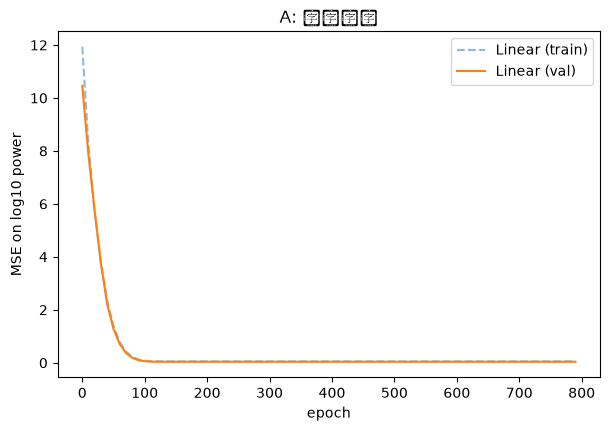

In [3]:
linear = torch.nn.Linear(3, 1)
hist_a = train_model(linear)
print(f"最终 train loss {hist_a[-1,1]:.4f} | val loss {hist_a[-1,2]:.4f}")
plot_histories([hist_a], ['Linear'], 'A: 线性模型')

## 实验 B：加一个隐藏层（MLP）

结构：`Linear(3, 64) -> ReLU -> Linear(64, 1)`。

和线性模型唯一的区别是中间多了一个非线性层。预测：val loss 会下降还是上升？为什么？

最终 train loss 0.0333 | val loss 0.0377


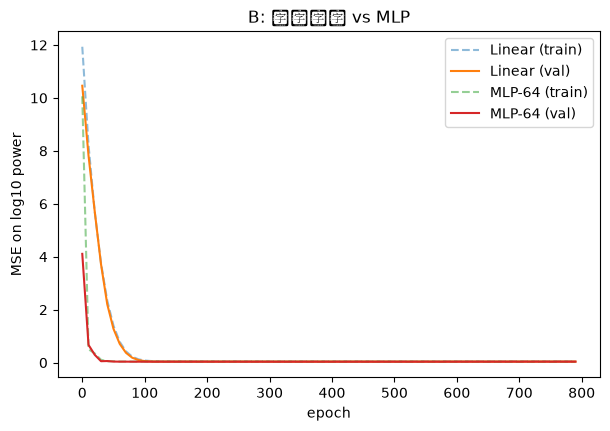

In [4]:
def make_mlp(hidden):
    return torch.nn.Sequential(
        torch.nn.Linear(3, hidden),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden, 1),
    )

mlp64 = make_mlp(64)
hist_b = train_model(mlp64)
print(f"最终 train loss {hist_b[-1,1]:.4f} | val loss {hist_b[-1,2]:.4f}")
plot_histories([hist_a, hist_b], ['Linear', 'MLP-64'], 'B: 线性模型 vs MLP')

## 实验 C：隐藏层越大越好吗？

分别试 hidden = 4 / 64 / 512。训练集只有约 155 台机器，观察哪个容量开始让 val loss 变差。

hidden=  4 | 最终 train 0.0437 | val 0.0385
hidden= 64 | 最终 train 0.0333 | val 0.0377
hidden=512 | 最终 train 0.0258 | val 0.0444


/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


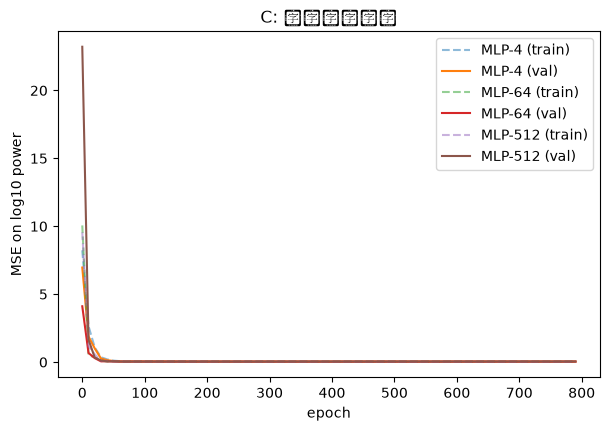

In [5]:
hists_c, labels_c = [], []
for hidden in [4, 64, 512]:
    hist = train_model(make_mlp(hidden))
    hists_c.append(hist)
    labels_c.append(f'MLP-{hidden}')
    print(f"hidden={hidden:3d} | 最终 train {hist[-1,1]:.4f} | val {hist[-1,2]:.4f}")
plot_histories(hists_c, labels_c, 'C: 模型容量对比')

## 实验 D：权重衰减（weight decay）

对最大的 MLP-512 施加 `weight_decay=0.1`，观察 val 曲线是否被拉回来。

最终 train loss 0.0531 | val loss 0.0413


/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 34928 (\N{CJK UNIFIED IDEOGRAPH-8870}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20943 (\N{CJK UNIFIED IDEOGRAPH-51CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


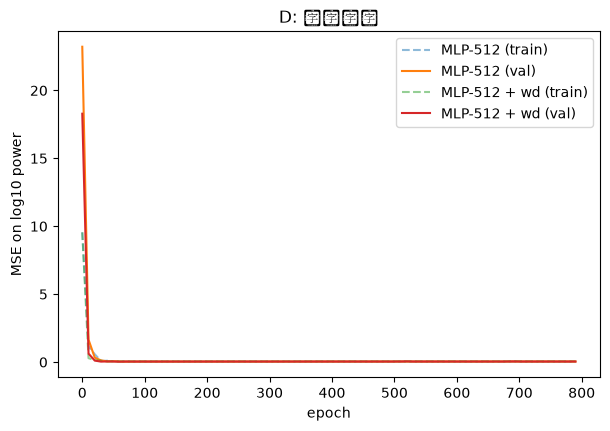

In [6]:
mlp512_wd = make_mlp(512)
hist_d = train_model(mlp512_wd, weight_decay=0.1)
print(f"最终 train loss {hist_d[-1,1]:.4f} | val loss {hist_d[-1,2]:.4f}")
plot_histories([hists_c[2], hist_d], ['MLP-512', 'MLP-512 + wd'], 'D: 权重衰减')

## 课堂讨论

1. 实验 C 里，hidden=512 的 train loss 几乎降到 0，val loss 却更差——这两件事同时告诉我们什么？
2. 如果论文里写 "we used a neural network"，审稿人/评委至少应该追问哪三个细节？
3. 对 TOP500 功率这个任务，你会选哪个模型写进论文？用哪条曲线作证？
4.（延伸）Dropout 是另一种正则化。它为什么只在训练时打开、验证时关闭？